# Статистика, DS-поток
## Марафон-домашка SM.7, практическая часть

**Правила:**

* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Прислать нужно **ноутбук в формате `ipynb`**.
* Следите за размером файлов. **Бот не может принимать файлы весом более 20 Мб.** Если файл получается больше, заранее разделите его на несколько.
* Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания все участники списывания будут сдавать устный зачет.**
* Решения, размещенные на каких-либо интернет-ресурсах, не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Для выполнения задания используйте этот ноутбук в качестве основы, **не исправляйте и не удаляйте условия!** Можно добавлять необходимое количество ячеек.
* Комментарии к решению пишите в markdown-ячейках.
* Выполнение задания (ход решения, выводы и пр.) должно быть осуществлено на русском языке.
* Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
* Если код будет не понятен проверяющему, оценка может быть снижена.
* Никакой код из данного задания при проверке запускаться не будет. *Если код студента не выполнен, недописан и т.д., то он не оценивается.*
* В каждой задаче не забывайте делать **пояснения и выводы**.


**Правила оформления теоретических задач:**

* Решения необходимо прислать в виде $\LaTeX$ в markdown-ячейках.
* В решениях поясняйте, чем вы пользуетесь, хотя бы кратко. Например, если пользуетесь независимостью, то достаточно подписи вида "*X и Y незав.*"
* Решение, в котором есть только ответ, и отсутствуют вычисления, оценивается в 0 баллов.


**Баллы за задание.**

* Задача 1 &mdash; 50 баллов;
* Задача 2 &mdash; 50 баллов;
* Задача 3 &mdash; 10 баллов;
* Задача 4 &mdash; 30 баллов.

Задачи разных типов учитываются в разных рейтингах.

**Важность задач:**

* *высокая:* задачи 1-3;
* *средняя:* задача 4;

Задачи расставлены в том порядке, в котором их наиболее логично выполнять.

In [ ]:
# Bot check

# HW_ID: ds_sm7
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: not final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as sps
from tqdm.notebook import tqdm

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid", font_scale=1.3, palette=['#7570b3','#e7298a','#66a61e','#1b9e77','#e6ab02','#d95f02'])

from statsmodels.stats.diagnostic import lilliefors
from collections import Counter

### Ссылки на использование ИИ

Если при решении задач использовался ИИ, укажи здесь публичные ссылки на все чаты с ИИ и поясни, для каких целей он применялся. Обрати внимание на <a href="https://thetahat.ru/courses/ai-rules" target="_top">правила</a>.

**Задача 1**
1. ссылка
    - для чего использована
    - для чего использована
2. ссылка
    - для чего использована

**Задача 2**
1. ссылка
    - для чего использована

_____
### Задача 1.

Рассмотрим выборку $X = (X_{1}, ..., X_{n}) \sim \mathcal{N}(\theta, 1)$. Проверяются гипотезы $\mathsf{H}_0\colon\ \theta = 0\ \ vs.\ \ \mathsf{H}_1\colon\ \theta\ > 0$.

Выпишите равномерно наиболее мощный критерий, который получен в предыдущем домашнем задании.

$$
\overline{X} > F^{-1}_{\mathcal{N}(0,\, \frac{1}{n})}(1 - \alpha)
$$


На практике если предполагается, что распределение статистики критерия $T(X)$ одинаково и непрерывно, то перед применением критерия можно проверить его на корректность следующим образом.
1. Генерируется множество искусственных выборок в предположении справедливости $\mathsf{H}_0$.
2. По каждой из выборок вычисляется p-value.
3. По всем p-value строится гистограмма, которая визуально проверяется на равномерность.

В AB-тестировании такая процедура часто носит название *AA-тестирование*.

Проверим корректность нашего критерия. Конечно, у нас случай довольно простой, тут и так "все понятно", но стоит отработать навык проверки.
Проведите эксперимент на $10^6$ выборок размера 100 и постройте гистограмму.

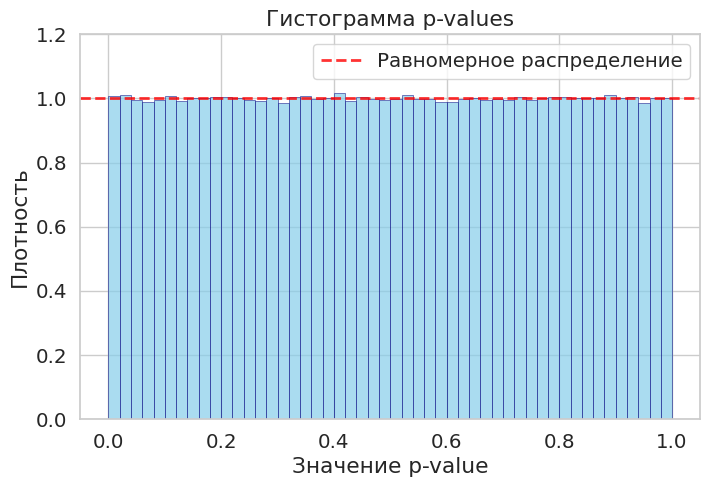

In [12]:
sample_size = 100  # размер выборки
sample_count = 10**6  # количество выборок

samples = sps.norm(loc=0, scale=1).rvs(size=(sample_count, sample_size))  # множество выборок
Z_stats = np.mean(samples, axis=1)  # статистика для каждой из выборок
pvalues = sps.norm(loc=0, scale=1/np.sqrt(sample_size)).sf(Z_stats)  # p-value для каждой из выборок

plt.figure(figsize=(8, 5))
plt.hist(pvalues, density=True, bins=50, alpha=0.7, color='skyblue', edgecolor='navy', linewidth=0.5)
plt.axhline(y=1, color='red', linestyle='--', alpha=0.8, linewidth=2, label='Равномерное распределение')
plt.xlabel('Значение p-value')
plt.ylabel('Плотность')
plt.title('Гистограмма p-values')
plt.ylim(0, 1.2)
plt.legend()
plt.show()

Как известно, критерий не меняется при рассмотрении сложной основной гипотезы $\mathsf{H}_0\colon\ \theta \leqslant 0\ \ vs.\ \ \mathsf{H}_1\colon\ \theta\ > 0$.

Повторите эксперимент для истинного $\theta=-0.1$.

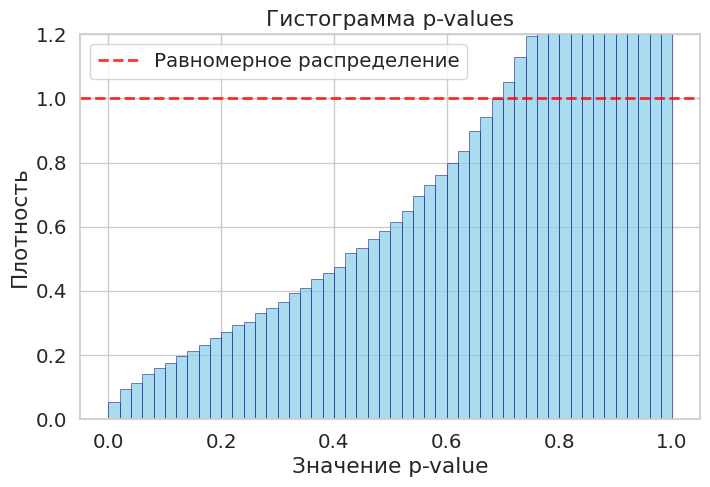

In [15]:
sample_size = 100  # размер выборки
sample_count = 10**6  # количество выборок

samples = sps.norm(loc=-0.1, scale=1).rvs(size=(sample_count, sample_size))  # множество выборок
Z_stats = np.mean(samples, axis=1)  # статистика для каждой из выборок
pvalues = sps.norm(loc=0, scale=1/np.sqrt(sample_size)).sf(Z_stats)  # p-value для каждой из выборок

plt.figure(figsize=(8, 5))
plt.hist(pvalues, density=True, bins=50, alpha=0.7, color='skyblue', edgecolor='navy', linewidth=0.5)
plt.axhline(y=1, color='red', linestyle='--', alpha=0.8, linewidth=2, label='Равномерное распределение')
plt.xlabel('Значение p-value')
plt.ylabel('Плотность')
plt.title('Гистограмма p-values')
plt.ylim(0, 1.2)
plt.legend()
plt.show()

*Замечание.* Подобный эффект все равно не дает оснований говорить об уверенности $\mathsf{H}_0$, поскольку критерий может быть недостаточно мощным.

Проверьте, как ведет себя p-value для альтернативы, рассмотрев истинную $\theta=0.1$.

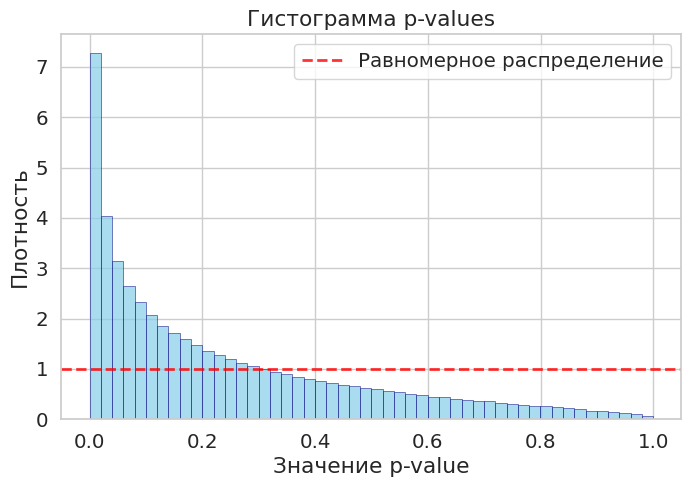

In [14]:
sample_size = 100  # размер выборки
sample_count = 10**6  # количество выборок

samples = sps.norm(loc=0.1, scale=1).rvs(size=(sample_count, sample_size))  # множество выборок
Z_stats = np.mean(samples, axis=1)  # статистика для каждой из выборок
pvalues = sps.norm(loc=0, scale=1/np.sqrt(sample_size)).sf(Z_stats)  # p-value для каждой из выборок

plt.figure(figsize=(8, 5))
plt.hist(pvalues, density=True, bins=50, alpha=0.7, color='skyblue', edgecolor='navy', linewidth=0.5)
plt.axhline(y=1, color='red', linestyle='--', alpha=0.8, linewidth=2, label='Равномерное распределение')
plt.xlabel('Значение p-value')
plt.ylabel('Плотность')
plt.title('Гистограмма p-values')
plt.legend()
plt.show()

In [11]:
print(f'Доля случаев, в которых p-value меньше 0.05: {np.mean(pvalues<0.05):.2f}')

Доля случаев, в которых p-value меньше 0.05: 0.26


Чему соответствует доля случаев, в которых p-value меньше 0.05?

Мощности критерия. Выборка генерировалась из распрделения соответствующего гипотезе $H_1$, а $H_0$ отвергается в случае p-value < 0.05. Вот и получается, что это доля случаев, когда мы отвергли гипотезу, при условии, что $H_1$ верно 

**Вывод:** При использовании понятия *p-value* нужно быть аккуратным. Если гипотеза $H_0$ **не отвергается**, то **ничего сказать нельзя** — *p-value* **не является степенью уверенности** в справедливости $H_0$.  

Большое значение *p-value* может означать как то, что $H_0$ действительно верна, так и то, что критерий просто **недостаточно мощный**, чтобы обнаружить отклонение от неё.




__________________
### Задача 2.

На лекциях и семинарах были разобраны следующие критерии проверки нормальности:
* Колмогорова;
* Жарка-Бера;
* Шапиро-Уилка.

Cуществует модификация критерия Колмогорова для проверки нормальности — <a href="https://ru.wikipedia.org/wiki/Критерий_Лиллиефорса"> Критерий Лиллиефорса.</a> При решении задачи можете воспользоваться им, например, взяв реализацию из библиотеки `statsmodels`: <a href="https://www.statsmodels.org/stable/generated/statsmodels.stats.diagnostic.lilliefors.html">`statsmodels.stats.diagnostic.lilliefors`</a>, или же применять для конкретной $F_0$ критерий Колмогорова, пример использования которого можно найти в ноутбуке с лекции.

**1.** Данные критерии являются асимптотическими, и их реальное значение уровня значимости может отличаться от желаемого числа $\alpha=0.05$. На семинарах разобран метод оценки реального уровня значимости критерия. Посчитайте реальный уровень значимости этих критериев для размеров выборки от 5 до 100.

*Подсказка:*

In [ ]:
max_sample_size = ...
sample_count = ...
is_reject_<критерий> = np.zeros((max_sample_size, sample_count))

for i in tqdm(range(max_sample_size)):
    for j in range(sample_count):
        sample = ...
        is_reject_<критерий>[i, j] = ...

Ваша реализация:

In [32]:
max_sample_size = 101
sample_count = 10**4
is_reject_lil = np.zeros((max_sample_size, sample_count))

n_range = range(5, max_sample_size)
for i in tqdm(n_range):
    for j in range(sample_count):
        sample = sps.norm(loc=5, scale=1).rvs(size=i)
        is_reject_lil[i, j] = lilliefors(sample, 'norm')[1] < 0.05

  0%|          | 0/96 [00:00<?, ?it/s]

In [33]:
max_sample_size = 101
sample_count = 10**4
is_reject_shap = np.zeros((max_sample_size, sample_count))

n_range = range(5, max_sample_size)
for i in tqdm(n_range):
    for j in range(sample_count):
        sample = sps.norm(loc=5, scale=1).rvs(size=i)
        is_reject_shap[i, j] = sps.shapiro(sample)[1] < 0.05

  0%|          | 0/96 [00:00<?, ?it/s]

In [34]:
max_sample_size = 101
sample_count = 10**4
is_reject_jarq = np.zeros((max_sample_size, sample_count))

n_range = range(5, max_sample_size)
for i in tqdm(n_range):
    for j in range(sample_count):
        sample = sps.norm(loc=5, scale=1).rvs(size=i)
        is_reject_jarq[i, j] = sps.jarque_bera(sample)[1] < 0.05

  0%|          | 0/96 [00:00<?, ?it/s]

Поясните, почему вы выбрали такое значение `sample_count`.

Значение 10^4 обеспечивает точность 0.01, но при этом не так вычислительно затратно, как, по моему мнению, оптимальное, 10^6

Нарисуйте на одном графике зависимость реального уровня значимости от размера выборки для каждого критерия. Пунктиром отметьте уровень 0.05. Не забудьте добавить легенду и подписать оси.

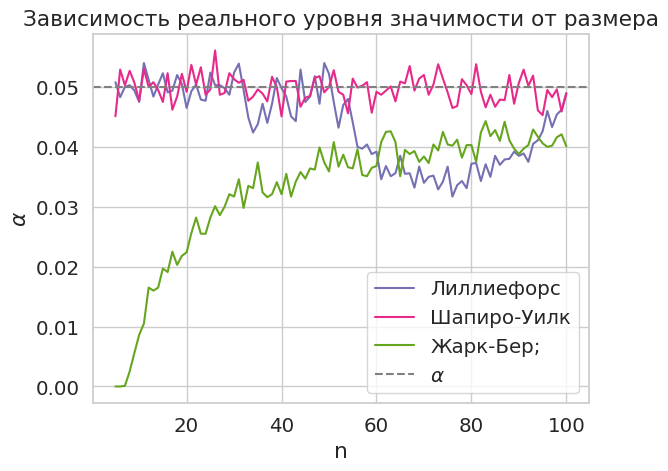

In [51]:
alpha_lil = np.mean(is_reject_lil, axis=1)
plt.plot(n_range, alpha_lil[5:], label='Лиллиефорс')
alpha_shap = np.mean(is_reject_shap, axis=1)
plt.plot(n_range, alpha_shap[5:], label='Шапиро-Уилк')
alpha_jarq = np.mean(is_reject_jarq, axis=1)
plt.plot(n_range, alpha_jarq[5:], label='Жарк-Бер;')
plt.axhline(0.05, c='gray', linestyle='--', label=r'$\alpha$')
plt.title('Зависимость реального уровня значимости от размера')
plt.xlabel('n')
plt.ylabel(r'$\alpha$')
plt.legend()
plt.show()

Какой можно сделать вывод?

С ростом выборки реальные уровни значимости критериев Лиллефорса и Шапиро-Уилка падают до уровня значимости $\hat{\alpha} \le \alpha$, а Шапиро-Уилка растёт, но тоже не более $\alpha$

**2.** Аналогичным образом можно вычислять мощность критерия. Вычислите мощности критериев для размеров выборки от 5 до 100, если альтернативная гипотеза заключается в том, что выборка имеет стандартное распределение Коши. Иначе говоря, для критерия $S$ надо приближенно посчитать $\beta_S(\mathsf{P})$, где $\mathsf{P}$ — стандартное распределение Коши.

Нарисуйте на одном графике зависимость мощности критерия от размера выборки для каждого критерия. Не забудьте добавить легенду и подписать оси.


In [57]:
max_sample_size = 101
sample_count = 10**4
is_reject_lil = np.zeros((max_sample_size, sample_count))

n_range = range(5, max_sample_size)
for i in tqdm(n_range):
    for j in range(sample_count):
        sample = sps.cauchy().rvs(size=i)
        is_reject_lil[i, j] = lilliefors(sample, 'norm')[1] < 0.05

  0%|          | 0/96 [00:00<?, ?it/s]

In [59]:
max_sample_size = 101
sample_count = 10**4
is_reject_shap = np.zeros((max_sample_size, sample_count))

n_range = range(5, max_sample_size)
for i in tqdm(n_range):
    for j in range(sample_count):
        sample = sps.cauchy().rvs(size=i)
        is_reject_shap[i, j] = sps.shapiro(sample)[1] < 0.05

  0%|          | 0/96 [00:00<?, ?it/s]

In [58]:
max_sample_size = 101
sample_count = 10**4
is_reject_jarq = np.zeros((max_sample_size, sample_count))

n_range = range(5, max_sample_size)
for i in tqdm(n_range):
    for j in range(sample_count):
        sample = sps.cauchy().rvs(size=i)
        is_reject_jarq[i, j] = sps.jarque_bera(sample)[1] < 0.05

  0%|          | 0/96 [00:00<?, ?it/s]

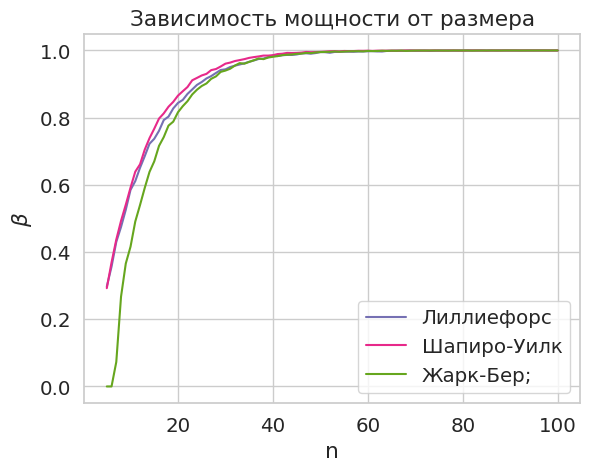

In [60]:
beta_lil = np.mean(is_reject_lil, axis=1)
plt.plot(n_range, beta_lil[5:], label='Лиллиефорс')
beta_shap = np.mean(is_reject_shap, axis=1)
plt.plot(n_range, beta_shap[5:], label='Шапиро-Уилк')
beta_jarq = np.mean(is_reject_jarq, axis=1)
plt.plot(n_range, beta_jarq[5:], label='Жарк-Бер;')
plt.title('Зависимость мощности от размера')
plt.xlabel('n')
plt.ylabel(r'$\beta$')
plt.legend()
plt.show()

Сделайте вывод. Какой критерий является наиболее мощным при данной альтернативе?

Наииболее мощным является критерий Шапиро-Уилка, но он же и является наиболее опасным с точки зрения ошибки первого рода, некоторый компромисс. Критерий Лиллиефорса работает похожим образом, а вот Жарка-Бера при малых размерах выборки обладает и вовсе нулевой мощностью. Однако и ошибка первого рода практически нулевая для него при малых размерах. При n порядка 50 все выходят на плато мощности 1

**3.** Распределение Стьюдента является в некотором смысле обобщением нормального распределения (при бесконечном количестве степеней свободы) и распределения Коши (при одной степени свободы).
Посчитайте приближенно мощности критериев для выборки размера 50 если альтернатива заключается в том, что выборка имеет распределение Стьюдента. Поскольку мощность критерия является функцией от распределения из альтернативной гипотезы, вам нужно посчитать функцию. Посчитайте её значения для целых значений степени свободы от 1 до 10.

Нарисуйте на одном графике зависимость мощности критерия от количества степеней свободы для каждого критерия. Не забудьте добавить легенду и подписать оси.

In [98]:
n = 50
max_df = 11
sample_count = 10**4
is_reject_jarq = np.zeros((max_df - 1, sample_count))

n_range = range(1, max_df)
for i in tqdm(n_range):
    for j in range(sample_count):
        sample = sps.t(df=i).rvs(size=n)
        is_reject_jarq[i - 1, j] = sps.jarque_bera(sample)[1] < 0.05

  0%|          | 0/10 [00:00<?, ?it/s]

In [100]:
n = 50
max_df = 11
sample_count = 10**4
is_reject_shap = np.zeros((max_df - 1, sample_count))

n_range = range(1, max_df)
for i in tqdm(n_range):
    for j in range(sample_count):
        sample = sps.t(df=i).rvs(size=n)
        is_reject_shap[i - 1, j] = sps.shapiro(sample)[1] < 0.05

  0%|          | 0/10 [00:00<?, ?it/s]

In [101]:
n = 50
max_df = 11
sample_count = 10**4
is_reject_lil = np.zeros((max_df - 1, sample_count))

n_range = range(1, max_df)
for i in tqdm(n_range):
    for j in range(sample_count):
        sample = sps.t(df=i).rvs(size=n)
        is_reject_lil[i - 1, j] = lilliefors(sample, 'norm')[1] < 0.05

  0%|          | 0/10 [00:00<?, ?it/s]

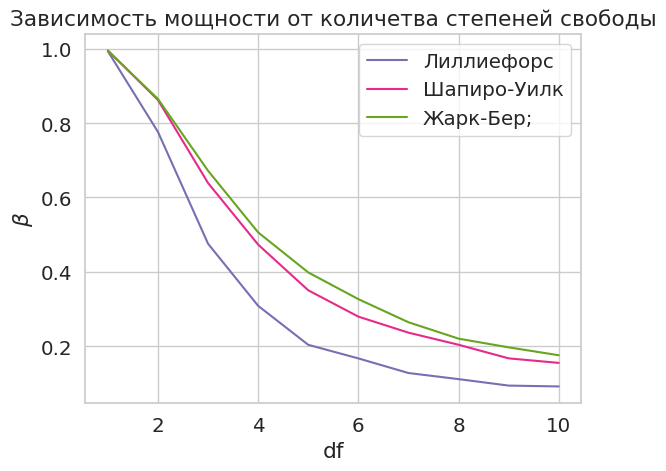

In [102]:
plt.plot(n_range, np.mean(is_reject_lil, axis=1), label='Лиллиефорс')
plt.plot(n_range, np.mean(is_reject_shap, axis=1), label='Шапиро-Уилк')
plt.plot(n_range, np.mean(is_reject_jarq, axis=1), label='Жарк-Бер;')
plt.title('Зависимость мощности от количетва степеней свободы')
plt.xlabel('df')
plt.ylabel(r'$\beta$')
plt.legend()
plt.show()

Сделайте вывод относительно мощности критерия при разных распределениях из альтернативы.

С ростом n наша альтернатива приближается к нормальном распрделению, а потому критерии всё меньше могут увидеть различий и реже отвергают гипотезу, что распрделение нормальное. Быстрее всего реагирует критерий Лиллиефорса, а медленнее - Жарк-Бер

___
### Задача 3.
Студенты периодически отправляют запросы в бот. Иногда бот бывает недоступен,
поэтому студенты с некоторыми интервалами повторяют запросы до тех пор, пока
бот не ответит. Известно, что $52$ запроса дошли с первой попытки, $31$ &mdash; со второй, $3$
&mdash; с третьей, а для доставки еще $5$ запросов потребовалось более $4$ попыток. Верно
ли, что бот получает запросы с вероятностью $\frac{2}{3}$?

**Решение:**

Пусть $H_0: p = \frac{2}{3}$ vs $H_1: p \ne \frac{2}{3}$

In [150]:
m1, m2, m3, m4 = 52, 31, 3, 5

n = m1 + m2 + m3 + m4

p = 2/3
q = 1 - p
p1, p2, p3, p4 = p, p*q, p*q**2, q**3 

n1, n2, n3, n4 = n*p1, n*p2, n*p3, n*p4

if sps.chisquare([m1, m2, m3, m4], f_exp=[n1, n2, n3, n4])[1] < 0.05:
    print('Не верно')
else:
    print('Верно')

Не верно


**Вывод:** Критерий хи-квадрат позволяет проверить гипотезу по экспериментальным данным

____
### Задача 4.

С помощью критерия хи-квадрат вам нужно проверить, правильно ли `scipy.stats` генерирует случайные величины.

**1.** Реализуйте критерий для генерации выборки $U\{1, ..., 10\}$, аналогично разобранному на семинаре. Тем самым проверьте, что `sps.randint` действительно генерирует выборку из равномерного распределения.

<...>

**2.** Проверьте, действительно ли код `sps.poisson(mu=5).rvs(size=1000)` генерирует выборку размера 1000 из пуассоновского распределения с параметром 5.

**Указания**
1. Не забудьте учесть условия применимости критерия хи-квадрат;
2. Для вычисления плотности воспользуйтесь `sps.poisson(mu=5).pmf`;
3. Для подсчета количества элементов в разбиении на множества воспользуйтесь `np.unique(sample, return_counts=True)`;
4. Не нужно писать сколь-либо универсальный код, который одним нажатием кнопки проверяет гипотезу с учетом всех условий применимости критерия. Расписывайте код поэтапно, на каждый логический этап свой код в отдельной ячейке для *конкретной* реализации выборки. Так вам проще реализовать, а нам проще проверять.

**Решение:**

Выполним пункт 1

In [324]:
sample_size = 1000  # размер выборки
sample_count = 100000  # количество выборок
chisq_values = np.zeros(sample_count)  # хи-квадрат статистики

for i in tqdm(range(sample_count)):
    # Генерируем выборку, 10 различных значений
    sample = sps.randint(low=1, high=11).rvs(size=sample_size)
    # применяем критерий
    f_obs = np.array(list(Counter(sample).values()))
    chisq_values[i] = sps.chisquare(f_obs)[0]

  0%|          | 0/100000 [00:00<?, ?it/s]

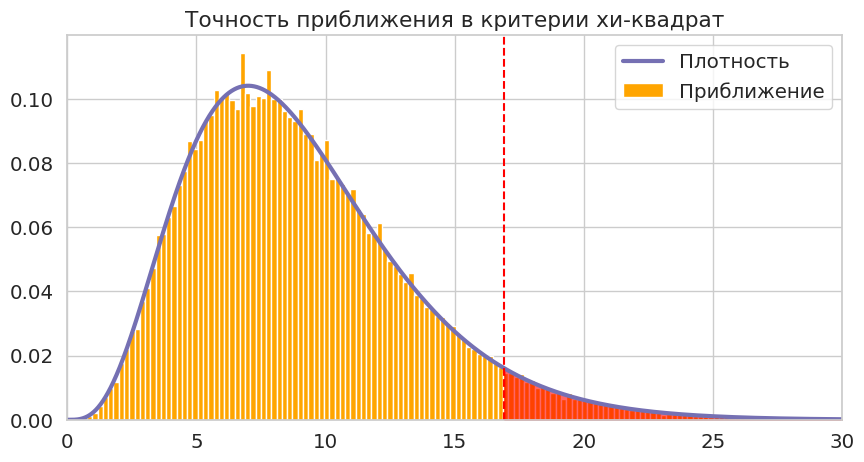

In [325]:
alpha = 0.05
plt.figure(figsize=(10, 5))
grid = np.linspace(0, 30, 10000)
plt.plot(grid, sps.chi2(df=9).pdf(grid),
         lw=3, label='Плотность')
plt.hist(chisq_values, bins=200,
         color='orange', density=True, label='Приближение')
plt.axvline(sps.chi2(df=9).ppf(1 - alpha), c='r', linestyle='--')
plt.title('Точность приближения в критерии хи-квадрат')
plt.fill_between(np.linspace(sps.chi2(df=9).ppf(1 - alpha), 30, 10000),
                 0,  sps.chi2(df=9).pdf(np.linspace(sps.chi2(df=9).ppf(1 - alpha), 30, 10000)),
                 alpha=0.6, color='r')
plt.xlim(0, 30)
plt.legend()
plt.show()

Видим, что при справедливости $H_0$ интересующая нас статистика действительно сходится по распрделению к хи-квадрат, значит мы не отвергаем гипотезу

In [284]:
sample = sps.poisson(mu=5).rvs(size=sample_size)
uniqs, counts = np.unique(sample, return_counts=True)
probs = sps.poisson(mu=5).pmf(uniqs)
f_exp = sample_size * probs

f_exp

array([6.73794700e+00, 3.36897350e+01, 8.42243375e+01, 1.40373896e+02,
       1.75467370e+02, 1.75467370e+02, 1.46222808e+02, 1.04444863e+02,
       6.52780393e+01, 3.62655774e+01, 1.81327887e+01, 8.24217669e+00,
       3.43424029e+00, 4.71736303e-01, 4.91391982e-02])

In [332]:
sample_size = 1000  # размер выборки
sample_count = 100000  # количество выборок
chisq_values = np.zeros(sample_count)  # хи-квадрат статистики

for i in tqdm(range(sample_count)):
    # Генерируем выборку, 10 различных значений
    sample = sps.poisson(mu=5).rvs(size=sample_size)
    # применяем критерий
    uniqs, f_obs = np.unique(sample, return_counts=True)
    probs = sps.poisson(mu=5).pmf(uniqs)
    f_exp = probs * sample_size
    # Немного подкорректируем частоты, чтобы критерий запустился
    diff = (np.sum(f_exp) - np.sum(f_obs)) / len(uniqs)
    chisq_values[i] = sps.chisquare(f_obs, f_exp=f_exp - diff)[0]

  0%|          | 0/100000 [00:00<?, ?it/s]

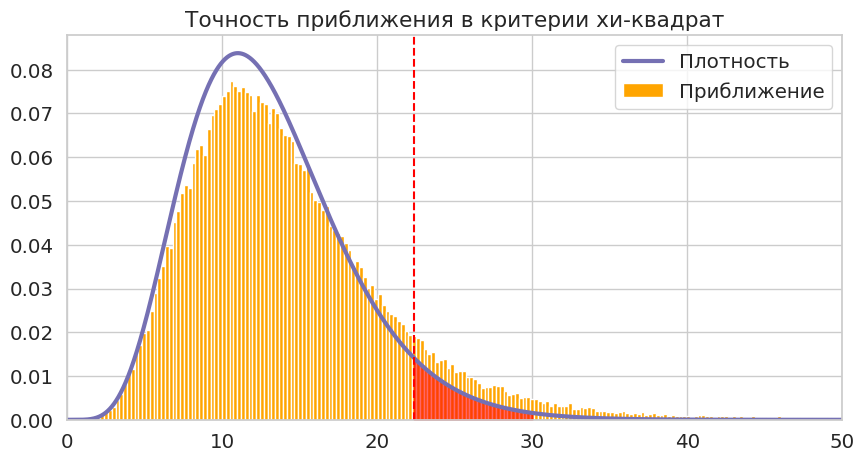

In [335]:
alpha = 0.05
plt.figure(figsize=(10, 5))
grid = np.linspace(0, 50, 10000)
plt.plot(grid, sps.chi2(df=len(uniqs)-1).pdf(grid),
         lw=3, label='Плотность')
plt.hist(chisq_values[chisq_values < 50], bins=200,
         color='orange', density=True, label='Приближение')
plt.axvline(sps.chi2(df=len(uniqs)-1).ppf(1 - alpha), c='r', linestyle='--')
plt.title('Точность приближения в критерии хи-квадрат')
plt.fill_between(np.linspace(sps.chi2(df=len(uniqs)-1).ppf(1 - alpha), 30, 10000),
                 0,  sps.chi2(df=len(uniqs)-1).pdf(np.linspace(sps.chi2(df=len(uniqs)-1).ppf(1 - alpha), 30, 10000)),
                 alpha=0.6, color='r')
plt.legend()
plt.xlim(0, 50)
plt.show()

Проверим применимость критерия для новой выборки

In [340]:
sample = sps.poisson(mu=5).rvs(size=sample_size)
uniqs, f_obs = np.unique(sample, return_counts=True)
probs = sps.poisson(mu=5).pmf(uniqs)
f_exp = probs * sample_size
diff = (np.sum(f_exp) - np.sum(f_obs)) / len(uniqs)
chisq_value = sps.chisquare(f_obs, f_exp=f_exp - diff)[0]

In [360]:
sample_size >= 50

True

Первое условие выполнено

In [368]:
print((f_exp >= 5))

[ True  True  True  True  True  True  True  True  True  True  True  True
 False False]


Здесь видим, что для больших частот $np_j^0$ меньше 5, поэтому для них критерий плохо применим

In [378]:
print(f'Число бакетов: {len(uniqs)}')
print(r'log(n):', np.log2(sample_size))

Число бакетов: 14
log(n): 9.965784284662087


Порядок тот же, значит 3 условие тоже выполнено

In [359]:
if chisq_value >= sps.chi2(df=len(uniqs)-1).ppf(1 - alpha):
    print('Гипотеза отвергается')
else:
    print('Гипотеза не отвергается')

Гипотеза не отвергается


**Вывод:**

Для критерий хи-квадрат должны хорошо выполняться условия, чтобы еи можно было пользоваться. Иначе возможны выбросы и неточности, нарушение теоремы о сходимости статистики